# 一人当たりに直して考えてみる

In [1]:
# csvファイル　country_population.csvを読み込む
import csv
with open(r"C:\修論研究\VWT_historical_data\country_population.csv", 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)
        

['Country Name', 'Country Code', 'Year', 'Value']
['Aruba', 'ABW', '1960', '54922']
['Aruba', 'ABW', '1961', '55578']
['Aruba', 'ABW', '1962', '56320']
['Aruba', 'ABW', '1963', '57002']
['Aruba', 'ABW', '1964', '57619']
['Aruba', 'ABW', '1965', '58190']
['Aruba', 'ABW', '1966', '58694']
['Aruba', 'ABW', '1967', '58990']
['Aruba', 'ABW', '1968', '59069']
['Aruba', 'ABW', '1969', '59052']
['Aruba', 'ABW', '1970', '58950']
['Aruba', 'ABW', '1971', '58781']
['Aruba', 'ABW', '1972', '58047']
['Aruba', 'ABW', '1973', '58299']
['Aruba', 'ABW', '1974', '58349']
['Aruba', 'ABW', '1975', '58295']
['Aruba', 'ABW', '1976', '58368']
['Aruba', 'ABW', '1977', '58580']
['Aruba', 'ABW', '1978', '58776']
['Aruba', 'ABW', '1979', '59191']
['Aruba', 'ABW', '1980', '59909']
['Aruba', 'ABW', '1981', '60563']
['Aruba', 'ABW', '1982', '61276']
['Aruba', 'ABW', '1983', '62228']
['Aruba', 'ABW', '1984', '62901']
['Aruba', 'ABW', '1985', '61728']
['Aruba', 'ABW', '1986', '59931']
['Aruba', 'ABW', '1987', '59159'

# netを人口で割ってみる

In [2]:
from __future__ import annotations

from typing import Optional, Tuple

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm


ISO3_FIX = {
    "FR": "FRA",
    "UK": "GBR",
    "EL": "GRC",
    "SP": "ESP",
    "SW": "SWE",
    "NO": "NOR",
    "JA": "JPN",
    "KO": "KOR",
    "CH": "CHN",
    "FR1": "FRA",
}

USSR_ALIASES = {"USSR", "SUN", "USS"}
USSR_NAME_ALIASES = {
    "USSR",
    "SOVIET UNION",
    "UNION OF SOVIET SOCIALIST REPUBLICS",
}


def _normalize_zip_shp_path(path: str) -> str:
    path = str(path)
    if path.startswith("zip://"):
        return path
    if ".zip!" in path.lower():
        return "zip://" + path
    return path


def _clean_iso3(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.upper()
    return s.replace({"": np.nan, "NAN": np.nan, "NONE": np.nan, "-99": np.nan})


def _find_column(columns, *, exact=None, contains=None) -> Optional[str]:
    exact = exact or []
    contains = contains or []

    lowered = {str(c).strip().lower(): c for c in columns}
    for key in exact:
        if key.lower() in lowered:
            return lowered[key.lower()]

    for c in columns:
        low = str(c).strip().lower()
        if any(token.lower() in low for token in contains):
            return c
    return None


def _make_world_iso3_key(world: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if "ISO_A3" not in world.columns:
        raise ValueError(f"world に ISO_A3 列が無い。columns={list(world.columns)}")

    world = world.copy()
    world["_iso3"] = _clean_iso3(world["ISO_A3"])
    invalid = world["_iso3"].isna()

    if "ADM0_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "ADM0_A3"])
        invalid = world["_iso3"].isna()

    if "SOV_A3" in world.columns:
        world.loc[invalid, "_iso3"] = _clean_iso3(world.loc[invalid, "SOV_A3"])
        invalid = world["_iso3"].isna()

    world["_iso3"] = world["_iso3"].replace(ISO3_FIX)
    world.loc[invalid, "_iso3"] = np.nan
    return world


def extract_population_by_iso3_for_year(
    population_df: pd.DataFrame,
    year: int,
    *,
    iso3_col: Optional[str] = None,
    year_col: Optional[str] = None,
    pop_col: Optional[str] = None,
    ussr_until_year: int = 1991,
) -> pd.DataFrame:
    if population_df is None or len(population_df) == 0:
        raise ValueError("population_df が空です。")

    pop = population_df.copy()
    y = int(year)

    if iso3_col is None:
        iso3_col = _find_column(
            pop.columns,
            exact=["iso3", "iso_a3", "iso-3", "iso_3", "country code", "country_code", "code"],
            contains=["iso3"],
        )
    if iso3_col is None:
        raise ValueError(
            f"人口データの ISO3 列を特定できません。iso3_col を指定してください。columns={list(pop.columns)}"
        )

    if year_col is not None or pop_col is not None:
        if year_col is None or pop_col is None:
            raise ValueError("year_col と pop_col はセットで指定してください。")
        long = pop[[iso3_col, year_col, pop_col]].copy()
        long["_year"] = pd.to_numeric(long[year_col], errors="coerce")
        long = long[long["_year"] == y]
        out = long[[iso3_col, pop_col]].rename(columns={iso3_col: "iso3", pop_col: "population"})
    else:
        year_col_wide = None
        for c in pop.columns:
            if str(c).strip() == str(y):
                year_col_wide = c
                break

        if year_col_wide is not None:
            out = pop[[iso3_col, year_col_wide]].rename(columns={iso3_col: "iso3", year_col_wide: "population"})
        else:
            auto_year_col = _find_column(pop.columns, exact=["year", "yr"], contains=["year"])
            auto_pop_col = _find_column(pop.columns, exact=["population", "pop", "value"], contains=["pop"])
            if auto_year_col is None or auto_pop_col is None:
                raise ValueError(
                    "人口データ形式を自動判定できません。"
                    " long形式なら year_col/pop_col、wide形式なら年列（例: '2015'）を確認してください。"
                )
            long = pop[[iso3_col, auto_year_col, auto_pop_col]].copy()
            long["_year"] = pd.to_numeric(long[auto_year_col], errors="coerce")
            long = long[long["_year"] == y]
            out = long[[iso3_col, auto_pop_col]].rename(columns={iso3_col: "iso3", auto_pop_col: "population"})

    out = out.copy()
    out["iso3"] = _clean_iso3(out["iso3"]).replace(ISO3_FIX)
    if y <= int(ussr_until_year):
        out["iso3"] = out["iso3"].replace({k: "RUS" for k in USSR_ALIASES})

    out["population"] = pd.to_numeric(out["population"], errors="coerce")
    out = out[out["iso3"].notna() & np.isfinite(out["population"]) & (out["population"] > 0)].copy()
    out = out.groupby("iso3", as_index=False)["population"].sum()
    return out


def plot_vwt_net_import_export_map_debug_percapita(
    year: int,
    crop: int,
    *,
    country_list_xlsx: str,
    vwt_npy_template: str,
    ne_countries_shp: str,
    population_df: pd.DataFrame,
    pop_iso3_col: Optional[str] = None,
    pop_year_col: Optional[str] = None,
    pop_value_col: Optional[str] = None,
    population_year: Optional[int] = None,
    xlim=(-180, 180),
    ylim=(-60, 85),
    top_n_print: int = 20,
    percapita_unit: str = "m^3/person/year",
    cmap: str = "seismic",
    clip_quantile: Optional[float] = 0.995,
    missing_color: str = "#BEBEBE",
    border_color: str = "#444444",
    border_lw: float = 0.35,
    show_missing_legend: bool = True,
    debug_iso3: str = "FRA",
    print_no_match_samples: int = 30,
    print_df_only_samples: int = 30,
    ussr_until_year: int = 1991,
) -> Tuple[pd.DataFrame, gpd.GeoDataFrame]:
    debug_iso3 = str(debug_iso3).strip().upper()
    y = int(year)
    pop_y = int(population_year) if population_year is not None else y
    pre_ussr = y <= int(ussr_until_year)

    if pre_ussr and debug_iso3 in USSR_ALIASES:
        debug_iso3 = "RUS"

    vwt_path = vwt_npy_template.format(crop=crop, year=year)
    vwt_mat = np.load(vwt_path).astype(float)
    if vwt_mat.ndim != 2:
        raise ValueError(f"VWTmat must be 2D. got shape={vwt_mat.shape}")

    nrow, ncol = vwt_mat.shape
    if nrow != ncol:
        print(f"[WARN] VWTmat is not square: {vwt_mat.shape}. row/colの向きを要確認")

    n = min(nrow, ncol)
    vwt_mat = vwt_mat[:n, :n]
    print("VWTmat shape:", vwt_mat.shape)
    print("VWT file:", vwt_path)

    cl = pd.read_excel(country_list_xlsx)
    iso3_col = _find_column(cl.columns, exact=["iso3", "iso_a3", "iso-3", "iso_3"], contains=["iso3"])
    if iso3_col is None:
        raise ValueError(f"country_list に ISO3 列が見つからない。columns={list(cl.columns)}")
    if len(cl) < n:
        raise ValueError(f"country_list rows ({len(cl)}) < VWT size ({n}). country_listの行数が足りない。")

    cl_n = cl.iloc[:n].copy()
    cl_n["_iso3_raw"] = cl_n[iso3_col].astype(str)
    cl_n["_iso3"] = _clean_iso3(cl_n["_iso3_raw"]).replace(ISO3_FIX)

    country_name_col = _find_column(cl_n.columns, exact=["country name", "country", "name"], contains=["country"])
    if country_name_col is None:
        country_name_col = cl_n.columns[0]

    cl_n["_country_upper"] = cl_n[country_name_col].astype(str).str.strip().str.upper()
    missing_iso = cl_n["_iso3"].isna()
    cl_n.loc[missing_iso & cl_n["_country_upper"].isin(USSR_NAME_ALIASES), "_iso3"] = "USSR"

    import_by_country = np.nansum(vwt_mat, axis=0)
    export_by_country = np.nansum(vwt_mat, axis=1)

    df_net = pd.DataFrame(
        {
            "iso3_raw": cl_n["_iso3"].values,
            "import": import_by_country,
            "export": export_by_country,
        }
    )
    if pre_ussr:
        df_net["iso3"] = df_net["iso3_raw"].replace({k: "RUS" for k in USSR_ALIASES})
    else:
        df_net["iso3"] = df_net["iso3_raw"]

    df_net = df_net[df_net["iso3"].notna()].copy()
    df_net = df_net.groupby("iso3", as_index=False)[["import", "export"]].sum()
    df_net["net"] = df_net["import"] - df_net["export"]

    pop_by_iso3 = extract_population_by_iso3_for_year(
        population_df=population_df,
        year=pop_y,
        iso3_col=pop_iso3_col,
        year_col=pop_year_col,
        pop_col=pop_value_col,
        ussr_until_year=ussr_until_year,
    )
    print(f"population year: {pop_y}, rows={len(pop_by_iso3)}")

    df_net = df_net.merge(pop_by_iso3, on="iso3", how="left")
    valid_pop = np.isfinite(df_net["population"]) & (df_net["population"] > 0)
    for col in ["import", "export", "net"]:
        df_net[f"{col}_pc"] = np.where(valid_pop, df_net[col] / df_net["population"], np.nan)

    print(f"population valid ratio: {int(valid_pop.sum())}/{len(df_net)}")

    df_pos = df_net[df_net["net_pc"] > 0].sort_values("net_pc", ascending=False)
    df_neg = df_net[df_net["net_pc"] < 0].sort_values("net_pc", ascending=True)
    print(f"\nTop {top_n_print} net per-capita positive (net_pc>0):")
    print(df_pos.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])
    print(f"\nTop {top_n_print} net per-capita negative (net_pc<0):")
    print(df_neg.head(top_n_print)[["iso3", "population", "import_pc", "export_pc", "net_pc"]])

    ne_countries_shp = _normalize_zip_shp_path(ne_countries_shp)
    world = gpd.read_file(ne_countries_shp)
    world = _make_world_iso3_key(world)
    m = world.merge(df_net, left_on="_iso3", right_on="iso3", how="left")

    print("\n" + "=" * 70)
    print(f"[DEBUG] Investigate ISO3 = {debug_iso3}")
    print("=" * 70)
    print(f"[DEBUG] world has {debug_iso3}? ->", (world["_iso3"] == debug_iso3).any())
    print(f"[DEBUG] df_net has {debug_iso3}? ->", (df_net["iso3"] == debug_iso3).any())
    if (df_net["iso3"] == debug_iso3).any():
        print(df_net[df_net["iso3"] == debug_iso3][["iso3", "population", "import_pc", "export_pc", "net_pc"]].head(5))

    no_match = m[m["_iso3"].notna() & m["net_pc"].isna()][["_iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample world-iso3 but missing in df_net/pop (no match): n={len(no_match)}")
    print(no_match.head(print_no_match_samples).to_string(index=False))

    net_only = df_net[~df_net["iso3"].isin(world["_iso3"].dropna())][["iso3"]].drop_duplicates()
    print(f"\n[DEBUG] sample df_net iso3 but missing in world: n={len(net_only)}")
    print(net_only.head(print_df_only_samples).to_string(index=False))
    print("=" * 70 + "\n")

    vals = m["net_pc"].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        raise ValueError("net_pc の有効値が無い（人口マージ失敗 or population<=0）。")

    absvals = np.abs(vals)
    if clip_quantile is not None:
        q = float(clip_quantile)
        if not (0 < q <= 1):
            raise ValueError("clip_quantile must be in (0, 1].")
        vmax = float(np.nanquantile(absvals, q))
        if not np.isfinite(vmax) or vmax <= 0:
            vmax = float(np.nanmax(absvals))
    else:
        vmax = float(np.nanmax(absvals))

    if vmax == 0:
        vmax = 1.0

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    fig, ax = plt.subplots(1, 1, figsize=(14, 7))
    ax.set_axis_off()
    ax.set_title(f"Virtual-water net per capita (import - export) [{percapita_unit}] | {year} (crop={crop})", fontsize=14)

    m.plot(ax=ax, color=missing_color, linewidth=0.0, edgecolor="none", zorder=1)
    has = np.isfinite(m["net_pc"].astype(float))
    m.loc[has].plot(
        ax=ax,
        column="net_pc",
        cmap=cmap,
        norm=norm,
        linewidth=0.0,
        edgecolor="none",
        legend=True,
        zorder=2,
    )
    m.boundary.plot(ax=ax, color=border_color, linewidth=border_lw, zorder=3)

    if show_missing_legend:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[Patch(facecolor=missing_color, edgecolor="none", label="No data / no match / no population")],
            loc="lower left",
            frameon=True,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

    return df_net, m


VWTmat shape: (255, 255)
VWT file: C:\修論研究\VWT_historical_data\VWT_npy\VWT_15_2015.npy
population year: 2015, rows=265
population valid ratio: 210/231

Top 20 net per-capita positive (net_pc>0):
    iso3  population   import_pc  export_pc      net_pc
51   DJI   1020313.0  887.584105   0.000000  887.584105
219  VCT    106960.0  386.665567   0.033478  386.632088
64   FJI    918578.0  374.811525   0.008324  374.803201
97   ISR   8380100.0  326.836472   0.105164  326.731308
80   GRD    114676.0  268.624882   0.000000  268.624882
201  TJK   8643840.0  262.875872   0.000000  262.875872
13   AZE   9649341.0  251.559671   0.000000  251.559671
156  OMN   4184895.0  240.326985   1.865239  238.461747
71   GEO   3725276.0  233.978533   0.318230  233.660303
113  LBY   6531819.0  218.569587   0.560686  218.008902
109  KWT   3834574.0  210.946450   0.042352  210.904098
207  TUN  11402264.0  199.703133   0.000000  199.703133
155  NZL   4609400.0  199.510970   0.449264  199.061706
131  MLT    444220.0 

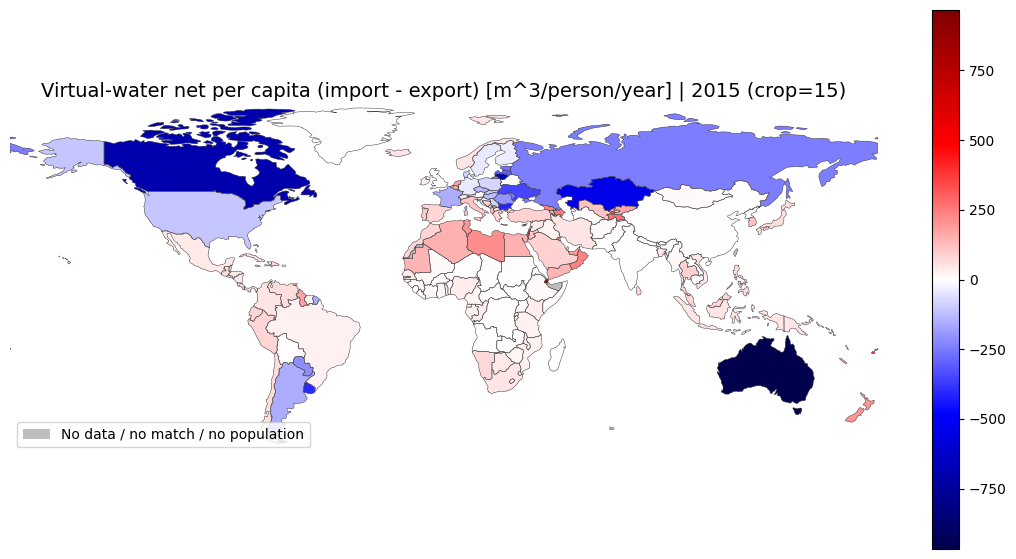

In [6]:
import csv
import pandas as pd
from percapita_utils import plot_vwt_net_import_export_map_debug_percapita

COUNTRY_POP_CSV   = r"C:\修論研究\VWT_historical_data\country_population.csv"
COUNTRY_LIST_XLSX = r"C:\修論研究\VWT_historical_data\country_list.xlsx"
VWT_NPY_TEMPLATE  = r"C:\修論研究\VWT_historical_data\VWT_npy\VWT_{crop}_{year}.npy"
NE_COUNTRIES_SHP  = r"C:\修論研究\ne_110m_admin_0_countries.zip!ne_110m_admin_0_countries.shp"

# country_population.csv を読み込み（Country Code, Year, Value）
rows = []
with open(COUNTRY_POP_CSV, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

country_population = pd.DataFrame(rows)

df_net_pc, merged_map_pc = plot_vwt_net_import_export_map_debug_percapita(
    year=2015,
    crop=15,
    country_list_xlsx=COUNTRY_LIST_XLSX,
    vwt_npy_template=VWT_NPY_TEMPLATE,
    ne_countries_shp=NE_COUNTRIES_SHP,
    population_df=country_population,
    pop_iso3_col="Country Code",
    pop_year_col="Year",
    pop_value_col="Value",
    debug_iso3="RUS",
)
